# Transmission Line Fire-Risk Analysis — Washington State

This notebook intersects CONUS electric power transmission lines with the OCR fire-risk
raster to rank lines by fire exposure, **scoped to Washington state**.

**Data sources:**
- Fire-risk raster: OCR Icechunk store (same dataset as the 100-locations demo)
- Transmission lines: [US Electric Power Transmission Lines](https://gis-fws.opendata.arcgis.com/datasets/fws::us-electric-power-transmission-lines/about) (HIFLD via USFWS, ~94k lines)

**Method:**
1. Load `rps_2011` and `rps_2047` from the Icechunk store and subset to Washington state
2. Load transmission lines from a zipped Shapefile URL (no download required)
3. Filter lines to those intersecting the Washington state extent
4. Rasterize lines onto the fire-risk grid (each line assigned a unique integer ID)
5. Convert RPS values to risk scores (0–10) using `rps_to_score`; score ≥ 9 ≈ RPS ≥ 1%, score ≥ 10 ≈ RPS ≥ 3%
6. Count pixels and compute % of line pixels at each threshold using `np.bincount` for both years
7. Rank and visualise with three-panel maps (present · future · difference) for each threshold and metric


In [1]:
import warnings

import geopandas as gpd
import icechunk
import matplotlib.colors as mcolors  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  – registers the .rio accessor on xarray
import xarray as xr
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.geometry import box

from ocr.risks.fire import rps_to_score

## Load the fire-risk raster

In [2]:
version = 'v1.1.0'
storage = icechunk.s3_storage(
    bucket='us-west-2.opendata.source.coop',
    prefix=f'carbonplan/carbonplan-ocr/output/fire-risk/tensor/production/{version}/ocr.icechunk',
    region='us-west-2',
    anonymous=True,
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session('main')

ds = xr.open_dataset(session.store, engine='zarr', chunks='auto')
ds

<xarray.Dataset> Size: 652GB
Dimensions:        (latitude: 97579, longitude: 208881)
Coordinates:
  * longitude      (longitude) float64 2MB -128.4 -128.4 ... -64.05 -64.05
  * latitude       (latitude) float64 781kB 22.43 22.43 22.43 ... 52.48 52.48
Data variables:
    bp_2011        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2011       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    crps_scott     (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2011_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_scott      (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2047       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

## Subset raster to Washington state and inspect

Clip the dataset to Washington state before rasterizing to keep
memory usage low and keep the analysis focused.

In [3]:
# Bounding box for Washington state
WEST_LON = (-124.8, -116.9)
WEST_LAT = (45.5, 49.0)

lat_all = ds['latitude'].values
if lat_all[0] < lat_all[-1]:  # south-to-north
    ds_west = ds.sel(
        latitude=slice(WEST_LAT[0], WEST_LAT[1]),
        longitude=slice(WEST_LON[0], WEST_LON[1]),
    )
else:  # north-to-south
    ds_west = ds.sel(
        latitude=slice(WEST_LAT[1], WEST_LAT[0]),
        longitude=slice(WEST_LON[0], WEST_LON[1]),
    )

lat = ds_west['latitude'].values
lon = ds_west['longitude'].values

dlat = abs(float(lat[1] - lat[0]))
dlon = abs(float(lon[1] - lon[0]))
height, width = len(lat), len(lon)

print('Washington state subset')
print(f'Grid size:    {height:,} rows × {width:,} cols  ({height * width / 1e6:.1f} M pixels)')
print(f'Pixel size:   Δlat={dlat:.6f}°  Δlon={dlon:.6f}°')
print(
    f'Extent:       lon [{lon.min():.3f}, {lon.max():.3f}]  lat [{lat.min():.3f}, {lat.max():.3f}]'
)

Washington state subset
Grid size:    11,364 rows × 25,650 cols  (291.5 M pixels)
Pixel size:   Δlat=0.000308°  Δlon=0.000308°
Extent:       lon [-124.800, -116.900]  lat [45.500, 49.000]


## Load transmission lines

Geopandas reads the zipped Shapefile directly from the ArcGIS Hub URL via GDAL's `/vsicurl/` driver; no manual download required. The zipped Shapefile is the most compact binary option available from this dataset and streams efficiently.

In [4]:
# Zipped Shapefile from ArcGIS Hub — streamed directly
TRANSMISSION_LINES_URL = 'https://services2.arcgis.com/FiaPA4ga0iQKduv3/arcgis/rest/services/US_Electric_Power_Transmission_Lines/FeatureServer/replicafilescache/US_Electric_Power_Transmission_Lines_-8378795084787321001.zip'

print('Loading transmission lines …')
lines_raw = gpd.read_file(TRANSMISSION_LINES_URL)
print(f'Loaded {len(lines_raw):,} transmission lines')
lines_raw.head()

Loading transmission lines …
Loaded 94,619 transmission lines


,OBJECTID_1,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,Shape__Len,geometry
0,1,100000,OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2015-07-07,IMAGERY,2016-02-17,NOT AVAILABLE,-999999.0,NOT AVAILABLE,N,UNKNOWN128553,TAP139917,2250.169338,"LINESTRING (-9397293.05 5271551.21, -9397292.7..."
1,2,100001,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2014-05-02,IMAGERY,2020-04-16,ALABAMA POWER CO,115.0,100-161,Y,UNKNOWN109715,TAP142776,19187.282587,"LINESTRING (-9759902.182 3555017.969, -9759682..."
2,3,100002,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861, https://www.tva.gov/file_sou...",2014-04-24,IMAGERY,2019-03-11,TENNESSEE VALLEY AUTHORITY,161.0,100-161,Y,UNKNOWN109571,TAP144762,5619.797126,"LINESTRING (-9846204.435 3972849.122, -9846202..."
3,4,100003,NOT AVAILABLE,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,2016-12-09,UNVERIFIED,2016-12-09,PPL ELECTRIC UTILITIES CORP,-999999.0,NOT AVAILABLE,N,UNKNOWN125207,TAP147512,481.780072,"LINESTRING (-8551403.671 4998187.632, -8551258..."
4,5,100004,OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2014-08-21,IMAGERY,2014-08-21,NOT AVAILABLE,-999999.0,UNDER 100,Y,UNKNOWN115971,TAP142027,21.152123,"LINESTRING (-10364012.79 3727502.382, -1036401..."


## Filter transmission lines to Washington state extent

In [5]:
print(f'Native CRS of transmission lines: {lines_raw.crs}')

# Reproject to WGS84 so the bbox filter works in the same coordinate space as the raster
if lines_raw.crs is not None and not lines_raw.crs.equals('EPSG:4326'):
    lines_wgs84 = lines_raw.to_crs('EPSG:4326')
else:
    lines_wgs84 = lines_raw

west_bbox = box(float(lon.min()), float(lat.min()), float(lon.max()), float(lat.max()))

lines = (
    lines_wgs84[lines_wgs84.geometry.notna() & ~lines_wgs84.geometry.is_empty]
    .pipe(lambda df: df[df.geometry.intersects(west_bbox)])
    .reset_index(drop=True)
    .copy()
)

# 1-based integer index — used as the burn value during rasterization
lines['line_idx'] = np.arange(1, len(lines) + 1, dtype=np.int32)

print(f'Transmission lines in western states extent: {len(lines):,}')

Native CRS of transmission lines: EPSG:3857
Transmission lines in western states extent: 3,480


## Build the raster transform

We derive the affine transform from the dataset's coordinate arrays so the
rasterized line grid aligns exactly with the fire-risk pixels.

In [6]:
# Rasterio expects rows running north-to-south (y decreasing with row index).
# Detect orientation and record whether we need to flip the rps array later.
lat_flipped = lat[0] < lat[-1]  # True when ds stores south-to-north
lat_ns = lat[::-1] if lat_flipped else lat  # guaranteed north-to-south

transform = from_bounds(
    west=float(lon.min()) - dlon / 2,
    south=float(lat_ns[-1]) - dlat / 2,
    east=float(lon.max()) + dlon / 2,
    north=float(lat_ns[0]) + dlat / 2,
    width=width,
    height=height,
)
print('Affine transform:', transform)
print(f'Lat flip needed: {lat_flipped}')

Affine transform: | 0.00, 0.00,-124.80|
| 0.00,-0.00, 49.00|
| 0.00, 0.00, 1.00|
Lat flip needed: True


## Rasterize transmission lines

We burn each line's `line_idx` (1-based) into a grid that matches the fire-risk
raster exactly. Where multiple lines overlap, the last-burned value wins — this is
negligible at CONUS scale. Unoccupied pixels are 0.

In [7]:
print('Rasterizing transmission lines …')
shapes = (
    (geom, int(idx))
    for geom, idx in zip(lines.geometry, lines['line_idx'])
    if geom is not None and not geom.is_empty
)
line_raster = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='int32',
)
print(f'Line raster shape: {line_raster.shape}  dtype: {line_raster.dtype}')
print(f'Pixels with a line: {(line_raster > 0).sum():,}')

Rasterizing transmission lines …
Line raster shape: (11364, 25650)  dtype: int32
Pixels with a line: 952,226


## Compute fire risk scores for present and future

Convert continuous RPS values to categorical scores (0–10) using `rps_to_score`.

Working with score integers is far more memory-efficient than retaining float arrays.Masks are then derived for score ≥ 9 and score ≥ 10.

In [8]:
print('Computing fire risk scores for Washington (rps_2011 and rps_2047) …')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    score_2011 = rps_to_score(ds_west['rps_2011'].compute().values).astype(np.int8)
    score_2047 = rps_to_score(ds_west['rps_2047'].compute().values).astype(np.int8)

# Match north-to-south orientation of line_raster
if lat_flipped:
    score_2011 = score_2011[::-1, :]
    score_2047 = score_2047[::-1, :]

for thresh in [9, 10]:
    n11 = int((score_2011 >= thresh).sum())
    n47 = int((score_2047 >= thresh).sum())
    print(
        f'Score >= {thresh}  →  '
        f'present: {n11:,} px ({100 * n11 / score_2011.size:.2f}%)   '
        f'future:  {n47:,} px ({100 * n47 / score_2047.size:.2f}%)'
    )

Computing fire risk scores for Washington (rps_2011 and rps_2047) …
Score >= 9  →  present: 50,588,712 px (17.36%)   future:  89,363,000 px (30.66%)
Score >= 10  →  present: 31,566,557 px (10.83%)   future:  45,878,567 px (15.74%)


## Count high-risk pixels and percentages per line

**What's going on here in plain terms:**

Think of the fire-risk raster as a grid of tiny squares laid over Washington state — each square is one pixel. From the rasterization step we already know which pixel belongs to which transmission line (or to no line at all).

For each line we want to answer two questions:
1. **How many of its pixels have a high fire-risk score?** (raw count)
2. **What fraction of the line's total pixel footprint is high-risk?** (percentage)

We ask these questions twice — once for the "present" fire-risk map (2011) and once for the "future" map (2047) — and for two different risk thresholds (score ≥ 9 ≈ RPS ≥ 1%, score ≥ 10 ≈ RPS ≥ 3%).

Rather than looping over every line individually, `np.bincount` does the tallying in a single pass over all pixels at once, which is far faster. The difference column (future − present) shows how each line's exposure is expected to change: a positive number means more high-risk pixels in the future.


In [ ]:
# on_line marks every grid pixel that was burned with a line ID during rasterization.
# idx holds the 1-based line indices used to slice into np.bincount output.
on_line = line_raster > 0
idx = lines['line_idx'].values

# Count all rasterized pixels per line regardless of risk level — denominator for %.
# A guard against division by zero: lines too short relative to pixel resolution may
# rasterize to zero pixels.
total_per_line = np.bincount(line_raster[on_line], minlength=len(lines) + 1)[idx]

# Store in the dataframe for reference and downstream use.
lines['total_pixels'] = total_per_line


def _count(score_arr, threshold):
    # Joint mask: pixel must be on a line AND meet the score threshold.
    # np.bincount tallies matching pixels per line ID in a single O(N) pass —
    # far more efficient than iterating over each line individually.
    # [idx] extracts counts for lines present in the dataset, discarding zero-padded entries.
    mask = (score_arr >= threshold) & on_line
    return np.bincount(line_raster[mask], minlength=len(lines) + 1)[idx]


# Loop over both score thresholds (9 ≈ RPS ≥ 1%, 10 ≈ RPS ≥ 3%) and both years.
# For each combination: raw pixel count + percentage of the line's pixels that are high-risk.
for thresh in [9, 10]:
    for year, sarr in [('2011', score_2011), ('2047', score_2047)]:
        c = _count(sarr, thresh)

        # Raw count: how many of this line's rasterized pixels exceed the score threshold.
        lines[f'count_{year}_s{thresh}'] = c

        # Percentage: fraction of the line's total pixel footprint that is high-risk.
        # np.where guards against division by zero for lines with no rasterized pixels.
        lines[f'pct_{year}_s{thresh}'] = np.where(
            total_per_line > 0, 100.0 * c / total_per_line, 0.0
        )

    # Difference columns (future − present): positive = exposure increased, negative = decreased.
    lines[f'diff_count_s{thresh}'] = lines[f'count_2047_s{thresh}'] - lines[f'count_2011_s{thresh}']
    lines[f'diff_pct_s{thresh}'] = lines[f'pct_2047_s{thresh}'] - lines[f'pct_2011_s{thresh}']

print('Done. Columns added to `lines`:')
print([c for c in lines.columns if c.startswith(('count_', 'pct_', 'diff_', 'total_'))])
lines[
    [
        'ID',
        'OWNER',
        'total_pixels',
        'count_2011_s9',
        'count_2047_s9',
        'diff_count_s9',
        'pct_2011_s9',
        'pct_2047_s9',
    ]
].sort_values('count_2011_s9', ascending=False).head(10)

/var/folders/x0/v8j9bc4962dbwg_w3gytvf080000gn/T/ipykernel_59704/1058432608.py:18: RuntimeWarning: invalid value encountered in divide
  total_per_line > 0, 100.0 * c / total_per_line, 0.0
/var/folders/x0/v8j9bc4962dbwg_w3gytvf080000gn/T/ipykernel_59704/1058432608.py:18: RuntimeWarning: invalid value encountered in divide
  total_per_line > 0, 100.0 * c / total_per_line, 0.0


Done. Columns added to `lines`:
['count_2011_s9', 'pct_2011_s9', 'count_2047_s9', 'pct_2047_s9', 'diff_count_s9', 'diff_pct_s9', 'count_2011_s10', 'pct_2011_s10', 'count_2047_s10', 'pct_2047_s10', 'diff_count_s10', 'diff_pct_s10']


/var/folders/x0/v8j9bc4962dbwg_w3gytvf080000gn/T/ipykernel_59704/1058432608.py:18: RuntimeWarning: invalid value encountered in divide
  total_per_line > 0, 100.0 * c / total_per_line, 0.0
/var/folders/x0/v8j9bc4962dbwg_w3gytvf080000gn/T/ipykernel_59704/1058432608.py:18: RuntimeWarning: invalid value encountered in divide
  total_per_line > 0, 100.0 * c / total_per_line, 0.0


,ID,OWNER,count_2011_s9,count_2047_s9,diff_count_s9,pct_2011_s9,pct_2047_s9
10,200044,BONNEVILLE POWER ADMINISTRATION,2468,5144,2676,31.359593,65.362135
76,200125,BONNEVILLE POWER ADMINISTRATION,2326,3674,1348,32.078334,50.668873
43,200079,BONNEVILLE POWER ADMINISTRATION,2077,2448,371,45.910698,54.111406
1405,205726,PUGET SOUND ENERGY INC,2070,2665,595,65.589354,84.442332
44,200080,BONNEVILLE POWER ADMINISTRATION,2037,2411,374,44.867841,53.105727
147,200367,BONNEVILLE POWER ADMINISTRATION,1850,4403,2553,31.425174,74.791914
78,200127,BONNEVILLE POWER ADMINISTRATION,1684,3050,1366,21.177062,38.355131
482,200977,BONNEVILLE POWER ADMINISTRATION,1500,1876,376,32.844318,41.077294
79,200216,BONNEVILLE POWER ADMINISTRATION,1488,3734,2246,14.413018,36.168152
42,200078,BONNEVILLE POWER ADMINISTRATION,1340,1731,391,39.458186,50.971731


## Three-panel maps

Two metric sets: raw pixel count and percentage of line pixels.

Each figure shows the **top 25 lines** ranked by present-day exposure for the given threshold.Panels: present (2011) · future (2047) · difference (future − present).

In [10]:
ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(ne_url)
conus = world[world['ISO_A3'] == 'USA']


def three_panel_map(lines, col_present, col_future, col_diff, suptitle, cbar_label, diff_label):
    """Plot a three-panel (present / future / difference) map for the top-25 lines."""
    top25 = lines.nlargest(25, col_present)
    vmin = min(top25[col_present].min(), top25[col_future].min())
    vmax = max(top25[col_present].max(), top25[col_future].max())
    diff_abs = top25[col_diff].abs().max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    panel_cfg = [
        (col_present, 'YlOrRd', vmin, vmax, cbar_label, 'Present (2011)'),
        (col_future, 'YlOrRd', vmin, vmax, cbar_label, 'Future (2047)'),
        (col_diff, 'RdBu_r', -diff_abs, diff_abs, diff_label, 'Difference (2047 − 2011)'),
    ]
    for ax, (col, cmap, lo, hi, label, title) in zip(axes, panel_cfg):
        conus.plot(ax=ax, color='#f0ede8', edgecolor='#999', linewidth=0.4)
        lines.plot(ax=ax, color='#cccccc', linewidth=0.2, alpha=0.4)
        top25.plot(
            ax=ax,
            column=col,
            cmap=cmap,
            vmin=lo,
            vmax=hi,
            linewidth=2.5,
            legend=True,
            legend_kwds={'label': label, 'shrink': 0.7, 'orientation': 'horizontal', 'pad': 0.02},
        )
        ax.set_xlim(-125, -116)
        ax.set_ylim(45, 50.2)
        ax.set_title(title, fontsize=11)
        ax.set_axis_off()
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### Count maps: score ≥ 9 (RPS ≥ 1%) and score ≥ 10 (RPS ≥ 3%)

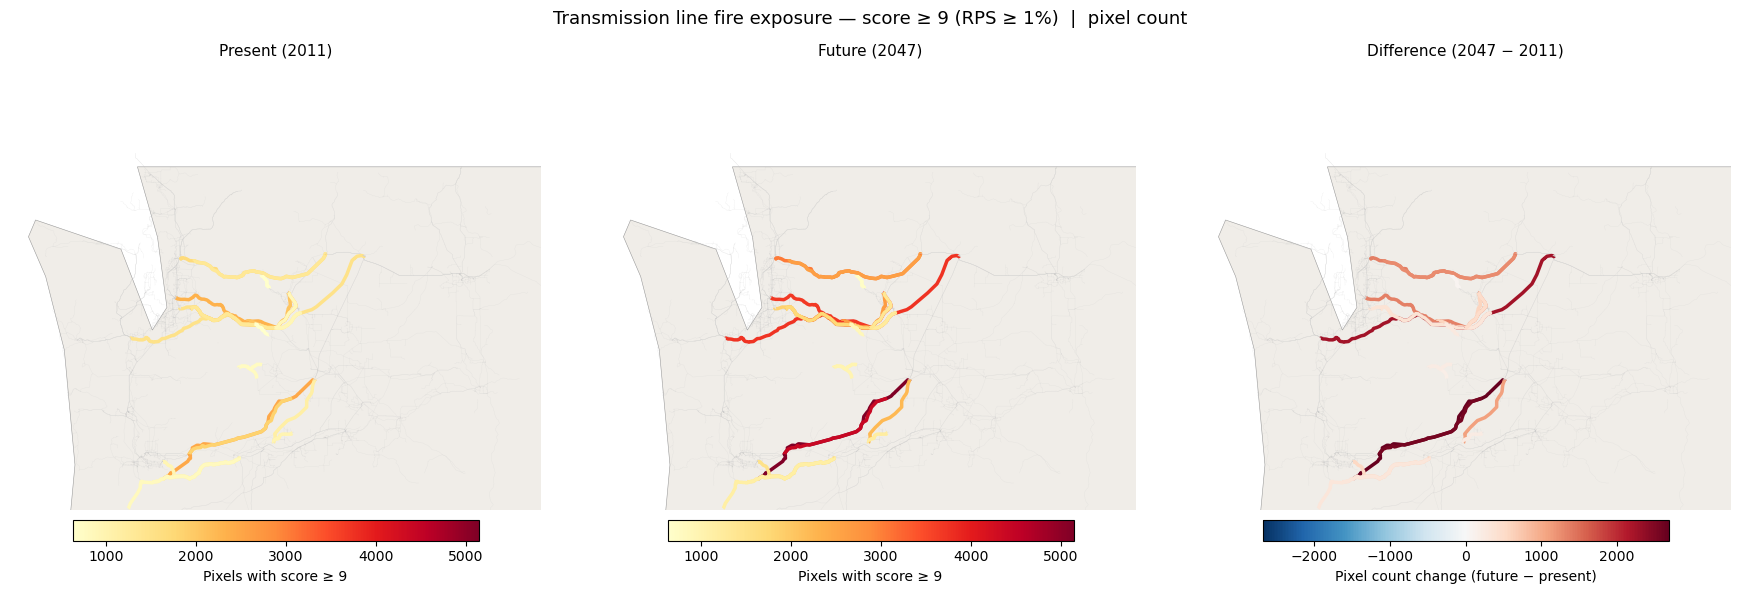

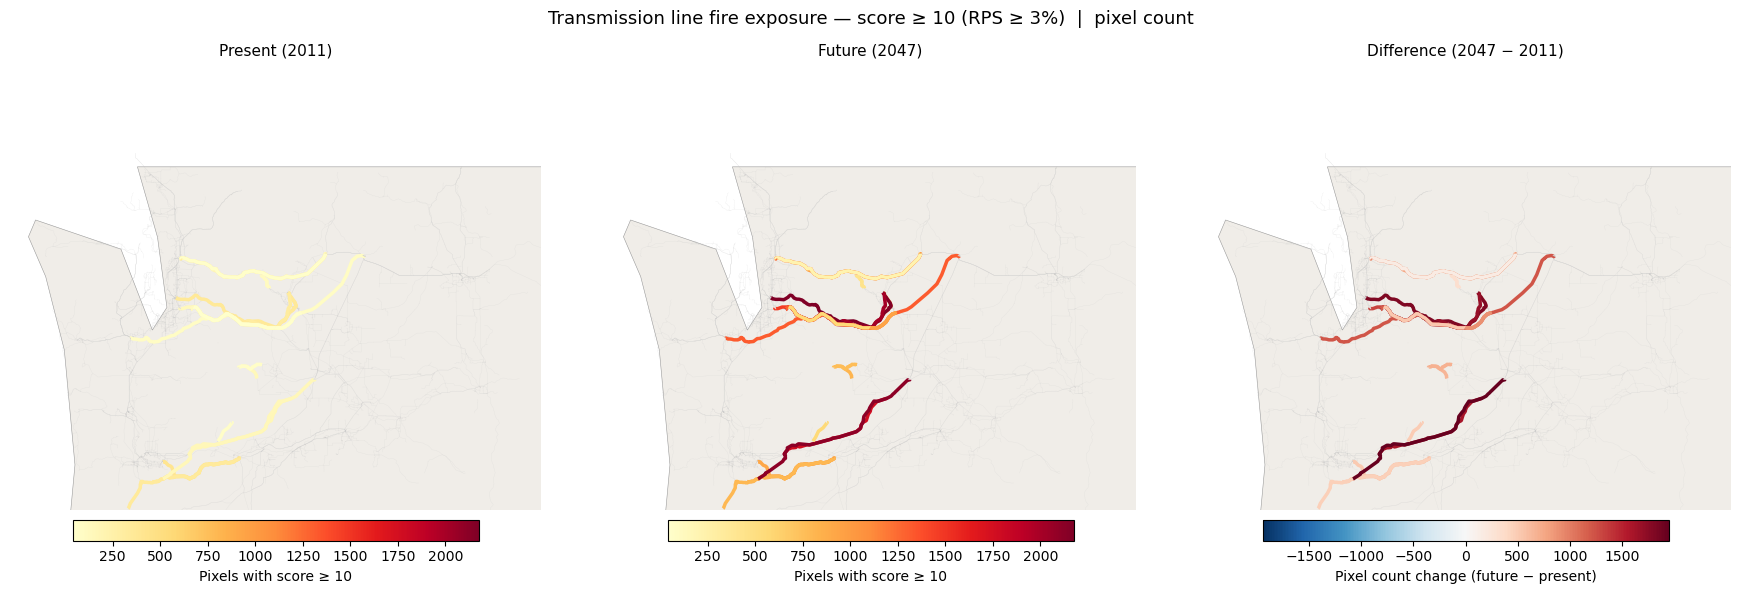

In [11]:
three_panel_map(
    lines,
    col_present='count_2011_s9',
    col_future='count_2047_s9',
    col_diff='diff_count_s9',
    suptitle='Transmission line fire exposure — score ≥ 9 (RPS ≥ 1%)  |  pixel count',
    cbar_label='Pixels with score ≥ 9',
    diff_label='Pixel count change (future − present)',
)

three_panel_map(
    lines,
    col_present='count_2011_s10',
    col_future='count_2047_s10',
    col_diff='diff_count_s10',
    suptitle='Transmission line fire exposure — score ≥ 10 (RPS ≥ 3%)  |  pixel count',
    cbar_label='Pixels with score ≥ 10',
    diff_label='Pixel count change (future − present)',
)

### Percentage maps: score ≥ 9 (RPS ≥ 1%) and score ≥ 10 (RPS ≥ 3%)

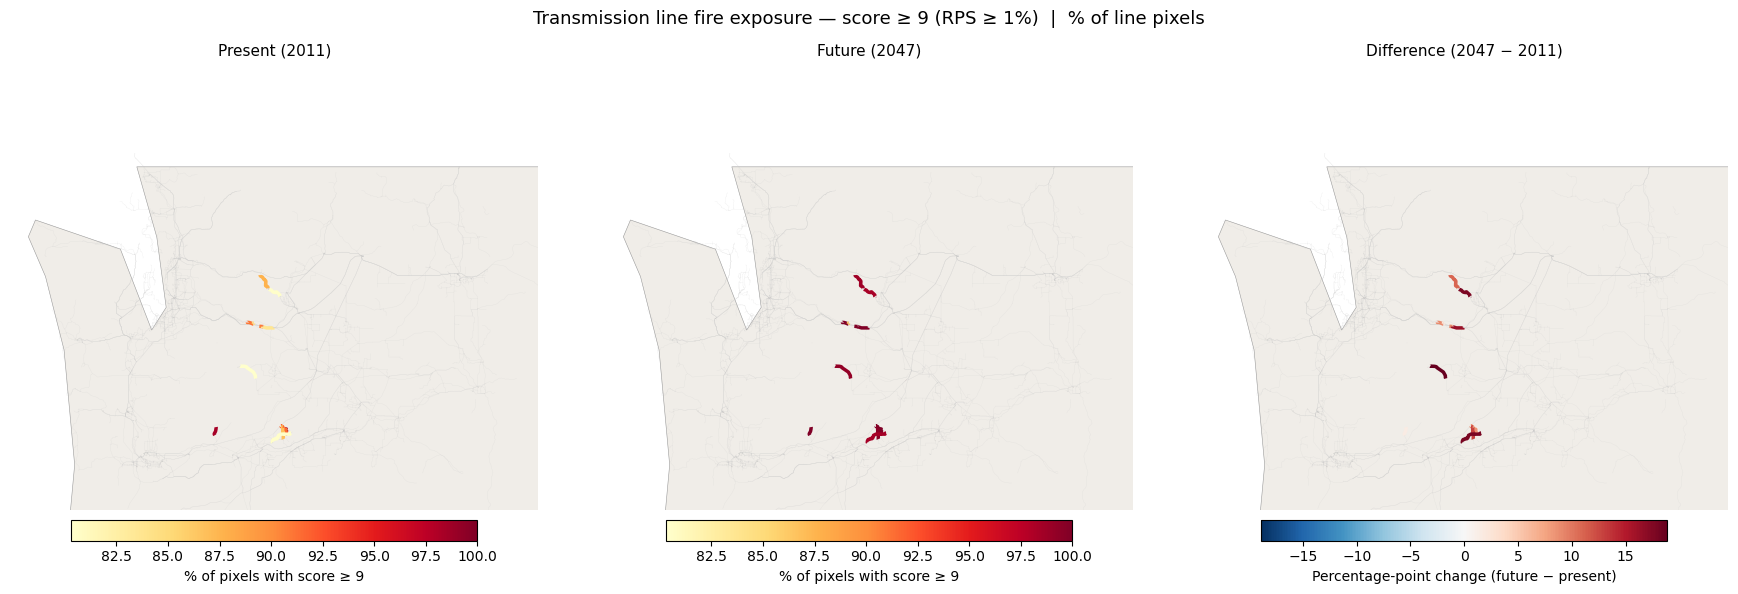

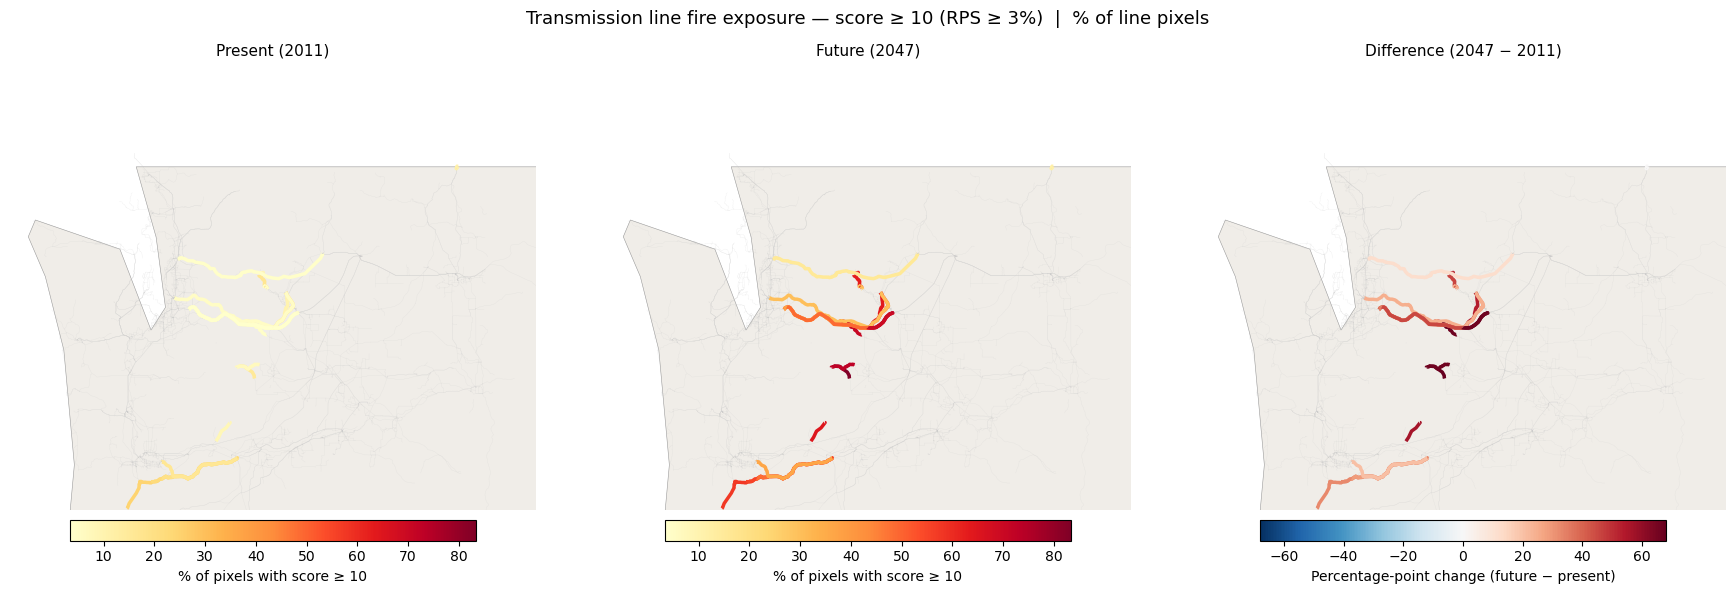

In [12]:
three_panel_map(
    lines,
    col_present='pct_2011_s9',
    col_future='pct_2047_s9',
    col_diff='diff_pct_s9',
    suptitle='Transmission line fire exposure — score ≥ 9 (RPS ≥ 1%)  |  % of line pixels',
    cbar_label='% of pixels with score ≥ 9',
    diff_label='Percentage-point change (future − present)',
)

three_panel_map(
    lines,
    col_present='pct_2011_s10',
    col_future='pct_2047_s10',
    col_diff='diff_pct_s10',
    suptitle='Transmission line fire exposure — score ≥ 10 (RPS ≥ 3%)  |  % of line pixels',
    cbar_label='% of pixels with score ≥ 10',
    diff_label='Percentage-point change (future − present)',
)

## Bar chart: top 25 lines ranked by high-risk pixel count

Side-by-side bars compare present (2011) and future (2047) exposure for the two
score thresholds. Lines are labelled by their `ID` field and sorted by present-day
score ≥ 9 count.


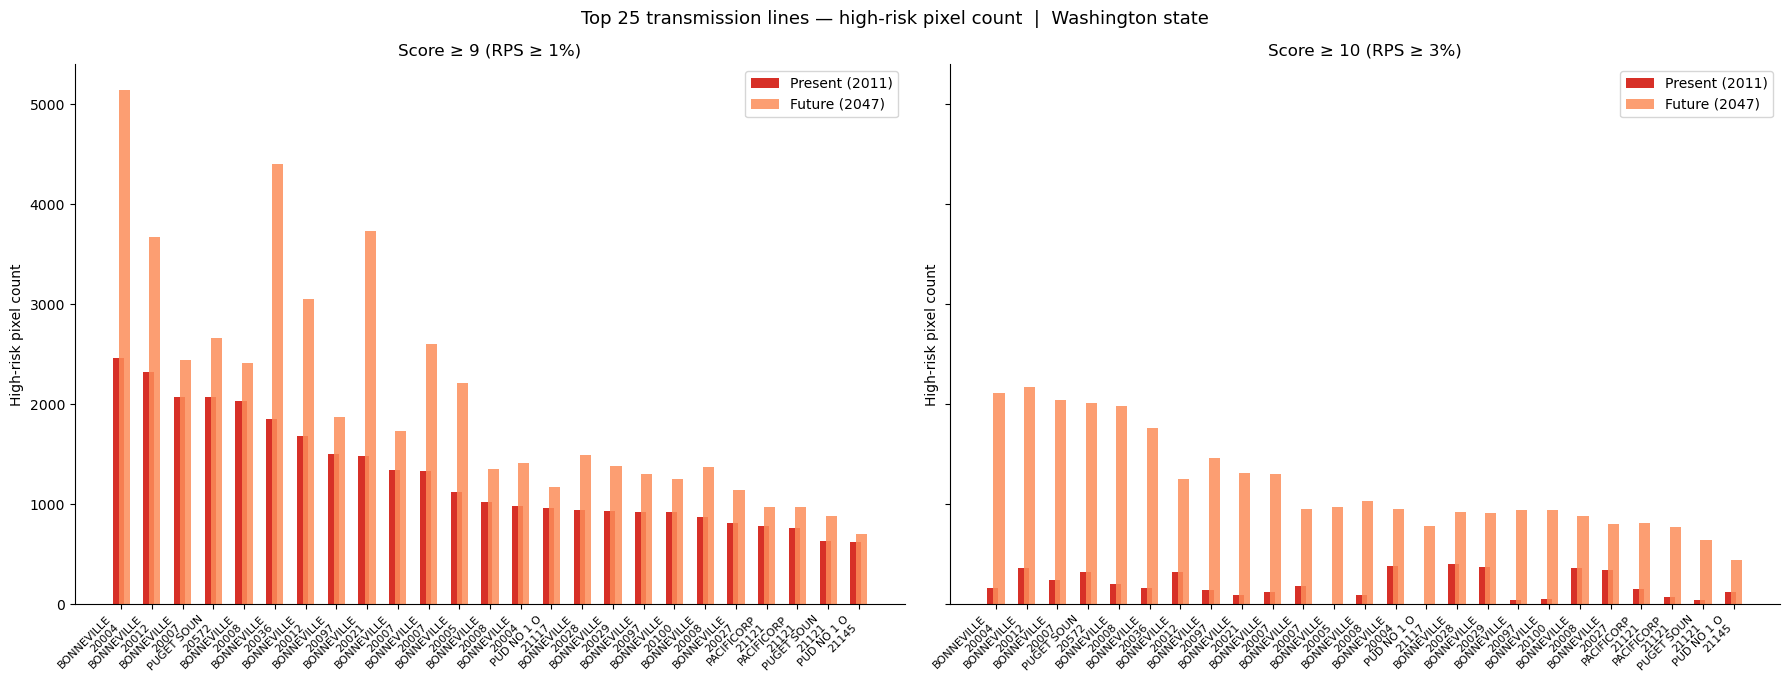

In [13]:
top25 = lines.nlargest(25, 'count_2011_s9').copy()
labels = (
    top25['OWNER'].fillna('Unknown').str[:10] + '\n' + top25['ID'].fillna('').astype(str).str[:5]
)
x = np.arange(len(top25))
bar_w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
titles = ['Score ≥ 9 (RPS ≥ 1%)', 'Score ≥ 10 (RPS ≥ 3%)']
suffixes = ['s9', 's10']

for ax, title, sfx in zip(axes, titles, suffixes):
    ax.bar(
        x - bar_w / 2,
        top25[f'count_2011_{sfx}'],
        bar_w * 2 * 0.9,
        label='Present (2011)',
        color='#d73027',
    )
    ax.bar(
        x + bar_w / 2,
        top25[f'count_2047_{sfx}'],
        bar_w * 2 * 0.9,
        label='Future (2047)',
        color='#fc8d59',
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('High-risk pixel count')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Top 25 transmission lines — high-risk pixel count  |  Washington state', fontsize=13)
plt.tight_layout()
plt.show()